In [1]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers.More2015 import More2015

In [2]:
importlib.reload(More2015)
More2015.Table1().df

Sample,logMmin,sigmalogM,logM1,alpha,kappa,Mstar11,Rc,psi,poff,Roff,alphainc,logMinc,omegaM,sigma8,100omegabh2,ns,h
Sample,,,,,,,,,,,,,,,,,
"[11.10,12.00]",13.13,0.22,14.21,1.13,1.25,0.0,0.98,0.93,0.34,2.2,0.44,13.57,0.310,0.785,2.228,0.964,0.703
"[11.30,12.0]",13.45,0.45,14.51,1.14,0.85,0.0,1.01,0.93,0.37,2.3,0.53,13.88,0.306,0.839,2.226,0.963,0.700
"[11.40,12.0]",13.68,0.79,14.56,1.00,1.19,0.0,1.02,0.94,0.36,2.4,0.57,14.08,0.304,0.813,2.222,0.961,0.695


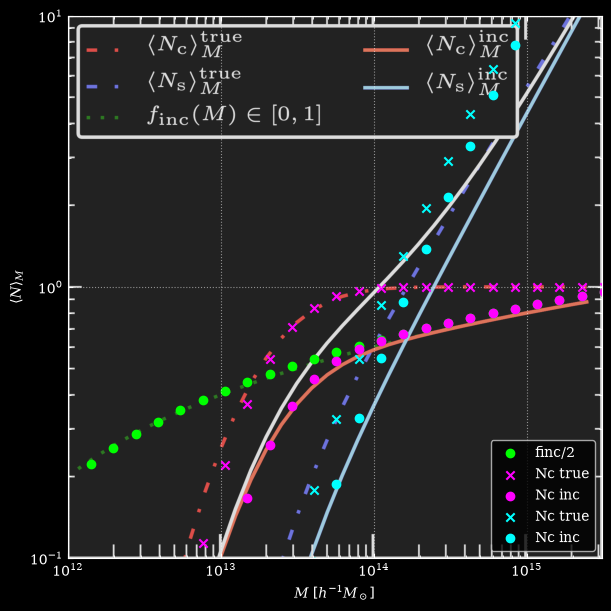

In [3]:
importlib.reload(More2015)

fig, ax = More2015.Fig2().full()

from Models import HODs

logMh = np.linspace(12, 15.5, 25)

M15 = HODs.More2015(mbin='MA')

p=M15.p0

finc_func = lambda logM: lambda p=M15.p0: (1+p['alpha_inc']*((logM-np.log10(M15.h**2))-p['logM_inc']))/2
ax.scatter(10**logMh/M15.h, finc_func(logMh)(p), c='lime', label='finc/2')

ax.scatter(10**logMh/M15.h, M15.Ncen(logMh)(p)/finc_func(logMh)(p), c='magenta', marker='x', label='Nc true')
ax.scatter(10**logMh/M15.h, M15.Ncen(logMh)(p), c='magenta', marker='o', label='Nc inc')

ax.scatter(10**logMh/M15.h, M15.Nsat(logMh)(p)/finc_func(logMh)(p), c='cyan', marker='x', label='Nc true')
ax.scatter(10**logMh/M15.h, M15.Nsat(logMh)(p), c='cyan', marker='o', label='Nc inc')

ax.legend(loc='lower right')
plt.show()

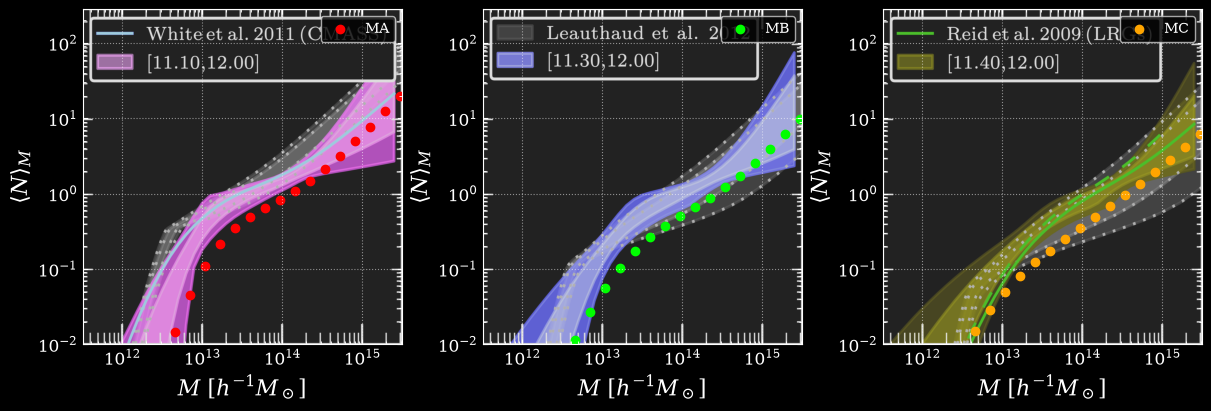

In [4]:
importlib.reload(More2015)
fig, axs = More2015.Fig4().full()

from Models import HODs


logMh = np.linspace(11, 15.5, 25)
pars = {'alpha_inc':0}

M15 = HODs.More2015({'mbin':'MA'})
axs[0].scatter(10**logMh/M15.h, M15.Ntot(logMh)(pars),c='red', label='MA')

M15 = HODs.More2015({'mbin':'MB'})
axs[1].scatter(10**logMh/M15.h, M15.Ntot(logMh)(pars),c='lime', label='MB')

M15 = HODs.More2015({'mbin':'MC'})
axs[2].scatter(10**logMh/M15.h, M15.Ntot(logMh)(pars),c='orange', label='MC')

axs[0].legend(); axs[1].legend(); axs[2].legend()
plt.show()